C:\Users\Admin\AppData\Local\Temp\ipykernel_15768\4118125745.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_metrics = df.groupby('symbol').apply(calculate_metrics).reset_index(drop=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_15768\4118125745.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='final_score', y='symbol', data=plot_data, palette=colors)


--- BẢNG XẾP HẠNG CỔ PHIẾU THEO Z-SCORE (TOP 10) ---
      symbol    close  return_1m  volatility_1m  z_return  z_volatility  \
34475    ROS   2.5100     0.0000         0.0000    0.8907       -2.8097   
35975    SAB  46.0000     0.0011         0.0090    0.9016       -1.7725   
29975    PLX  33.9000    -0.0044         0.0140    0.8466       -1.1988   
55168    VJC 176.5000     0.2377         0.0352    3.2687        1.2334   
37475    SBT  25.1000    -0.0669         0.0091    0.2214       -1.7582   
32975    REE  63.5000    -0.0201         0.0159    0.6900       -0.9766   
2991     BCM  66.0000    -0.0015         0.0184    0.8756       -0.6990   
49173    VCB  58.8000    -0.0681         0.0130    0.2090       -1.3129   
1496     ACB  24.8000    -0.0729         0.0139    0.1615       -1.2069   
13487    GAS  61.2000     0.0099         0.0216    0.9897       -0.3286   

       final_score  
34475       3.7004  
35975       2.6741  
29975       2.0454  
55168       2.0353  
37475       1.97

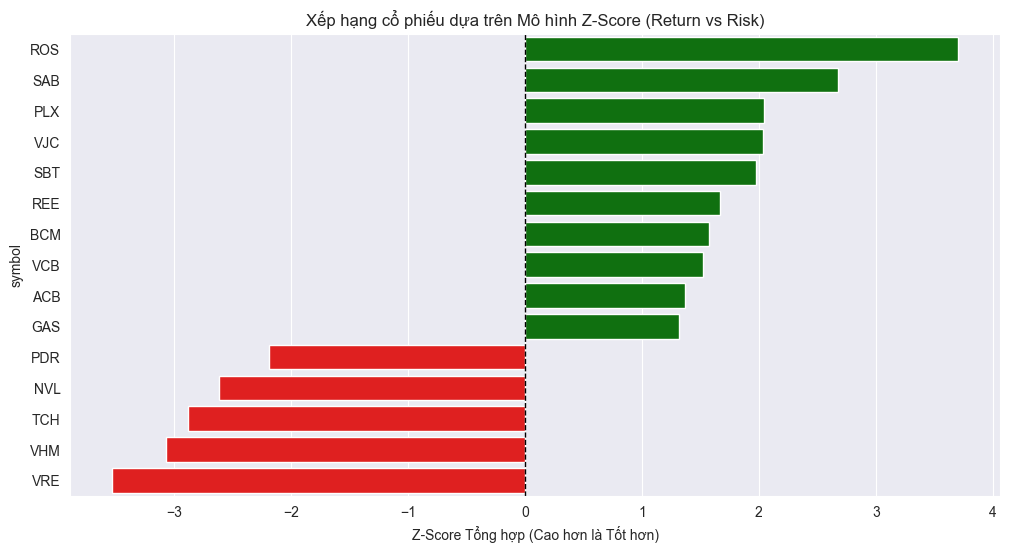

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('All_VN30_Merged.csv')

# Chuyển đổi định dạng thời gian và sắp xếp
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['symbol', 'time'])


# 2. Tính toán các chỉ số kỹ thuật (Feature Engineering)
# Chúng ta cần tính chỉ số trước, sau đó mới lấy lát cắt thời gian cuối cùng để so sánh
def calculate_metrics(group):
    # Lợi nhuận 1 tháng (20 phiên giao dịch)
    group['return_1m'] = group['close'].pct_change(20)

    # Độ biến động (Standard Deviation) của lợi nhuận ngày trong 1 tháng qua
    group['daily_return'] = group['close'].pct_change()
    group['volatility_1m'] = group['daily_return'].rolling(20).std()

    # Khối lượng giao dịch trung bình (để lọc thanh khoản nếu cần)
    group['avg_volume'] = group['volume'].rolling(20).mean()

    return group


# Áp dụng tính toán cho từng mã
df_metrics = df.groupby('symbol').apply(calculate_metrics).reset_index(drop=True)

# 3. Lấy dữ liệu phiên mới nhất của từng mã để so sánh (Cross-sectional analysis)
latest_snapshot = df_metrics.groupby('symbol').tail(1).copy()

# Loại bỏ các mã bị thiếu dữ liệu (NaN) do mới lên sàn hoặc ngừng giao dịch
latest_snapshot = latest_snapshot.dropna(subset=['return_1m', 'volatility_1m'])


# 4. Tính Z-Score (Chuẩn hóa dữ liệu)
def compute_zscore(series):
    return (series - series.mean()) / series.std()


# Z-Score cho Lợi nhuận (Càng cao càng tốt)
latest_snapshot['z_return'] = compute_zscore(latest_snapshot['return_1m'])

# Z-Score cho Biến động (Càng cao càng xấu -> Cần đảo dấu hoặc trừ đi khi tính tổng)
latest_snapshot['z_volatility'] = compute_zscore(latest_snapshot['volatility_1m'])

# 5. Tính điểm tổng hợp (Composite Score)
# Công thức: Ưu tiên Lợi nhuận cao + Rủi ro thấp
# Score = Z_Return - Z_Volatility
latest_snapshot['final_score'] = latest_snapshot['z_return'] - latest_snapshot['z_volatility']

# 6. Xếp hạng và Lọc Top 5
top_picks = latest_snapshot.sort_values(by='final_score', ascending=False)
result_table = top_picks[['symbol', 'close', 'return_1m', 'volatility_1m', 'z_return', 'z_volatility', 'final_score']]

print("--- BẢNG XẾP HẠNG CỔ PHIẾU THEO Z-SCORE (TOP 10) ---")
# Format lại hiển thị cho đẹp
pd.options.display.float_format = '{:,.4f}'.format
print(result_table.head(10))

# --- TRỰC QUAN HÓA KẾT QUẢ ---
plt.figure(figsize=(12, 6))
# Lấy Top 10 và Bottom 5 để so sánh
plot_data = pd.concat([top_picks.head(10), top_picks.tail(5)])

# Tạo màu: Xanh cho điểm dương, Đỏ cho điểm âm
colors = ['green' if x > 0 else 'red' for x in plot_data['final_score']]

sns.barplot(x='final_score', y='symbol', data=plot_data, palette=colors)
plt.title('Xếp hạng cổ phiếu dựa trên Mô hình Z-Score (Return vs Risk)')
plt.xlabel('Z-Score Tổng hợp (Cao hơn là Tốt hơn)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

# Xuất kết quả ra file nếu cần
# result_table.to_csv('Z_Score_Ranking.csv', index=False)